In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install ragas

In [ ]:
import os
import json
import numpy as np
import asyncio
import torch
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import statistics

from ragas import SingleTurnSample
from ragas.metrics import (
    LLMContextPrecisionWithoutReference as ContextPrecision,
    ResponseRelevancy,
    Faithfulness
)
from ragas.llms import LangchainLLMWrapper
from langchain_openai.chat_models import AzureChatOpenAI

from transformers import AutoTokenizer, AutoModel
from langchain_core.embeddings import Embeddings
from typing import List

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

openai_key=os.getenv("OPENAI_API_KEY")
azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT")

**Оценка ретривала (для вопросов)**

Precision и Recall для вопросов к mnn и trade_name считался по-разному.

Для **вопросов по mnn precision** равен отношению числа чанков с подходящим mnn к общему числу чанков топ 10 (т.е. 10):

<img src="precision_mnn.png" style="width:60%;" />

 Для **mnn вопросов recall** равен отношению числа чанков с подходящим mnn к общему числу чанков, которые могли бы быть найдены для данного mnn:
<img src="recall_mnn.png" style="width:70%;" />

Для **вопросов по trade_name precision** равен отношению числа чанков с совпадающим trade_name к общему числу чанков топ 10 (т.е. 10):
<img src="precision_trade_name.png" style="width:70%;" />

Для **trade_name вопросов recall** равен отношению числа чанков с подходящим trade_name к общему числу чанков, которые могли бы быть найдены для данного trade_name:
<img src="recall_trade_name.png" style="width:80%;" />

In [ ]:
qa_path = "/content/drive/MyDrive/Colab Notebooks/test_dataset_28_mnn.json"
corpus_meta = "/content/drive/MyDrive/Colab Notebooks/embedded_chunks/metadata.json" # метаданные для всех 560 инструкций

with open(qa_path, "r", encoding="utf-8") as f:
    qa_data = json.load(f)

with open(corpus_meta, "r", encoding="utf-8") as f:
    corpus_meta = json.load(f)

mnn_to_chunks   = defaultdict(set)
trade_to_chunks = defaultdict(set)

for item in corpus_meta:
    key = (item["file_name"], item["chunk_id"])
    mnn_to_chunks[item["mnn"]].add(key)
    trade_to_chunks[item["trade_name"]].add(key)

def eval_pr(question_chunks, relevant_set, K=10):
    topk = [(c["file_name"], c["chunk_id"]) for c in question_chunks[:K]]
    retrieved = set(topk)
    tp = len(retrieved & relevant_set)
    precision = tp / K
    recall    = tp / len(relevant_set) if relevant_set else 0.0
    return precision, recall

precisions, recalls = [], []

for mnn, entry in qa_data.items():
    # 1) вопросы по mnn
    rel = mnn_to_chunks.get(mnn, set())
    for block in entry.get("mnn_questions", []):
        p, r = eval_pr(block["question_chunks"], rel)
        precisions.append(p)
        recalls.append(r)

    # 2) вопросы по trade_name
    for tn, qlist in entry.get("trade_name_questions", {}).items():
        rel = trade_to_chunks.get(tn, set())
        for block in qlist:
            p, r = eval_pr(block["question_chunks"], rel)
            precisions.append(p)
            recalls.append(r)

mean_p = np.mean(precisions)
mean_r = np.mean(recalls)
print(f"Precision@10 (avg): {mean_p:.4f}")
print(f"Recall@10    (avg): {mean_r:.4f}")

Precision@10 (avg): 0.5325
Recall@10    (avg): 0.2504


Результаты

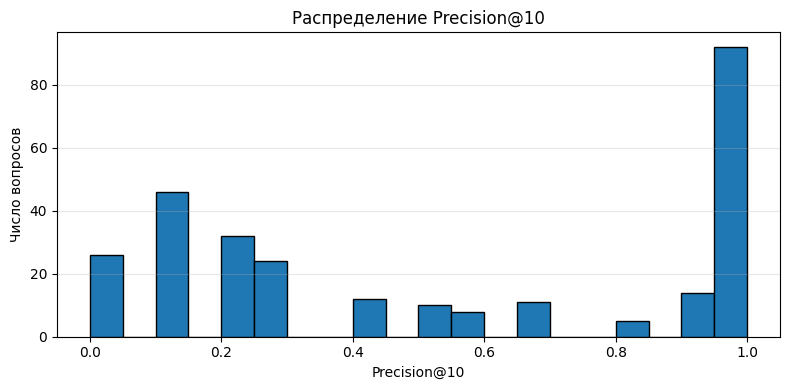

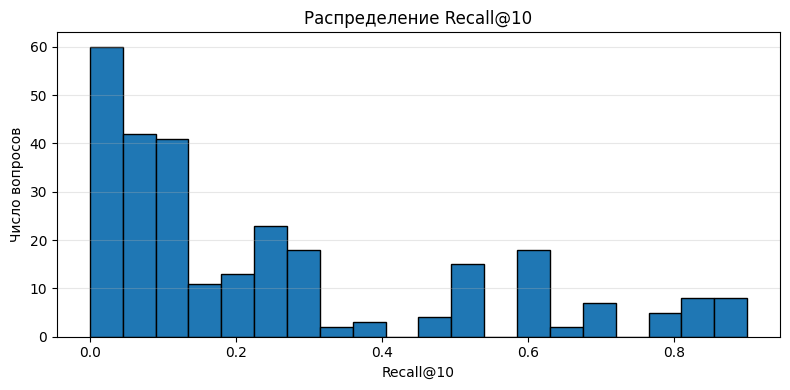

In [ ]:
# Precision@10
plt.figure(figsize=(8, 4))
plt.hist(precisions, bins=20, edgecolor='black')
plt.title("Распределение Precision@10")
plt.xlabel("Precision@10")
plt.ylabel("Число вопросов")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Recall@10
plt.figure(figsize=(8, 4))
plt.hist(recalls, bins=20, edgecolor='black')
plt.title("Распределение Recall@10")
plt.xlabel("Recall@10")
plt.ylabel("Число вопросов")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Оценка ответов**

Метрики из библиотеки Ragas:
- [LLM Based Context Precision without reference](https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/context_precision/#context-precision-without-reference)
<img src="context_precision.png" style="width:60%;" />

- [Response Relevancy](https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/answer_relevance/)
<img src="answer_relevancy.png" style="width:80%;" />

- [Faithfulness](https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/faithfulness/)
<img src="faithfulness.png" style="width:80%;" />

Для Response Relevancy требуются эмбеддинги

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

embeddings_folder = "/content/drive/MyDrive/Colab Notebooks/embedded_chunks"

class DeepVKEmbeddings(Embeddings):
    def __init__(self, model_name: str = "deepvk/USER-base", device: str = "cuda", batch_size: int = 16):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.device = device
        self.batch_size = batch_size
        self.model.to(device)
        self.model.eval()

    @staticmethod
    def mean_pooling(model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, dim=1)
        sum_mask = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        return sum_embeddings / sum_mask

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        all_embeddings = []
        for i in tqdm(range(0, len(texts), self.batch_size), desc="Векторизация"):
            batch = texts[i:i + self.batch_size]
            inputs = self.tokenizer(batch, return_tensors="pt", truncation=True, padding=True, max_length=512)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            with torch.no_grad():
                outputs = self.model(**inputs)
                embeddings = self.mean_pooling(outputs, inputs["attention_mask"]).cpu().numpy()
                all_embeddings.extend(embeddings)
        return all_embeddings

    def embed_query(self, text: str) -> List[float]:
        return self.embed_documents([text])[0]

embeddings = np.load(os.path.join(embeddings_folder, "embeddings.npy"))
with open(os.path.join(embeddings_folder, "metadata.json"), "r", encoding="utf-8") as f:
    metadata = json.load(f)
with open(os.path.join(embeddings_folder, "texts.json"), "r", encoding="utf-8") as f:
    texts = json.load(f)

embedding_model = DeepVKEmbeddings(device=device)

In [ ]:
api_version = "2024-12-01-preview"
deployment = "gpt-4o-3"
model_name = "gpt-4o"

azure_llm = AzureChatOpenAI(
    openai_api_key = os.getenv("OPENAI_API_KEY"),
    openai_api_version=api_version,
    azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT"),
    azure_deployment=deployment,
    model=model_name,
    validate_base_url=False,
)

In [ ]:
evaluator_llm = LangchainLLMWrapper(azure_llm)

device = "cuda" if torch.cuda.is_available() else "cpu"
evaluator_embeddings = DeepVKEmbeddings(
    model_name="deepvk/USER-base",
    device=device,
    batch_size=16
)

cp_metric = ContextPrecision(llm=evaluator_llm)
rr_metric = ResponseRelevancy(llm=evaluator_llm, embeddings=evaluator_embeddings)
f_metric  = Faithfulness(llm=evaluator_llm)

input_path  = "/content/drive/MyDrive/Colab Notebooks/test_dataset_28_mnn.json"
output_path = "/content/drive/MyDrive/Colab Notebooks/evaluated_test_dataset_28_mnn.json"

async def evaluate_dataset(input_path: str, output_path: str):
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # оценка одного блока
    async def eval_block(block: dict):
        sample = SingleTurnSample(user_input=block["question"],response=block["answer"],retrieved_contexts=[c["text"] for c in block["answer_chunks"]])
        cp = await cp_metric.single_turn_ascore(sample)
        rr = await rr_metric.single_turn_ascore(sample)
        f  = await f_metric.single_turn_ascore(sample)

        return {
            "context_precision":  float(cp),
            "response_relevancy": float(rr),
            "faithfulness":       float(f)
        }


    # по всем QA-блокам
    for entry in data.values():
        for block in entry.get("mnn_questions", []):
            block["metrics"] = await eval_block(block)
        for qlist in entry.get("trade_name_questions", {}).values():
            for block in qlist:
                block["metrics"] = await eval_block(block)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f"Saved annotated dataset to {output_path}")

if __name__ == "__main__":
    asyncio.run(evaluate_dataset(input_path , output_path))

Результаты

In [ ]:
evaluated_test_dataset = "/content/drive/MyDrive/Colab Notebooks/evaluated_test_dataset_28_mnn.json"

with open(evaluated_test_dataset, "r", encoding="utf-8") as f:
    data = json.load(f)

cp_vals = []
rr_vals = []
f_vals  = []

for entry in data.values():
    # mnn_questions
    for block in entry.get("mnn_questions", []):
        m = block["metrics"]
        cp_vals.append(m["context_precision"])
        rr_vals.append(m["response_relevancy"])
        f_vals.append(m["faithfulness"])
    # trade_name_questions
    for qlist in entry.get("trade_name_questions", {}).values():
        for block in qlist:
            m = block["metrics"]
            cp_vals.append(m["context_precision"])
            rr_vals.append(m["response_relevancy"])
            f_vals.append(m["faithfulness"])

results = {
    "mean_context_precision": statistics.mean(cp_vals),
    "mean_response_relevancy": statistics.mean(rr_vals),
    "mean_faithfulness": statistics.mean(f_vals),
    "median_context_precision": statistics.median(cp_vals),
    "median_response_relevancy": statistics.median(rr_vals),
    "median_faithfulness": statistics.median(f_vals),
    "std_context_precision": statistics.pstdev(cp_vals),
    "std_response_relevancy": statistics.pstdev(rr_vals),
    "std_faithfulness": statistics.pstdev(f_vals),
}

for name, val in results.items():
    print(f"{name}: {val:.4f}")

mean_context_precision: 0.8025
mean_response_relevancy: 0.6784
mean_faithfulness: 0.7439
median_context_precision: 0.9343
median_response_relevancy: 0.6821
median_faithfulness: 1.0000
std_context_precision: 0.2821
std_response_relevancy: 0.1809
std_faithfulness: 0.3442


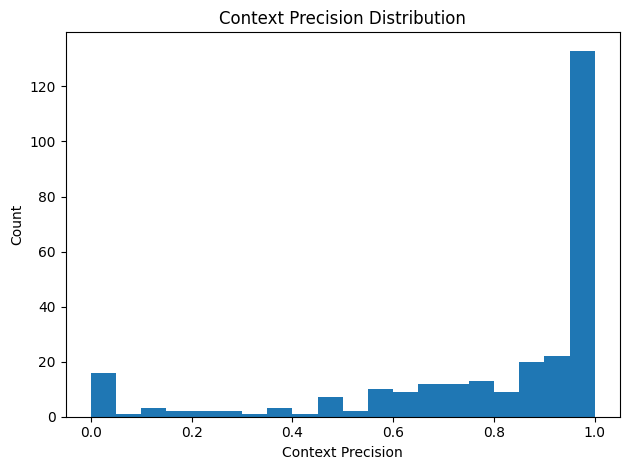

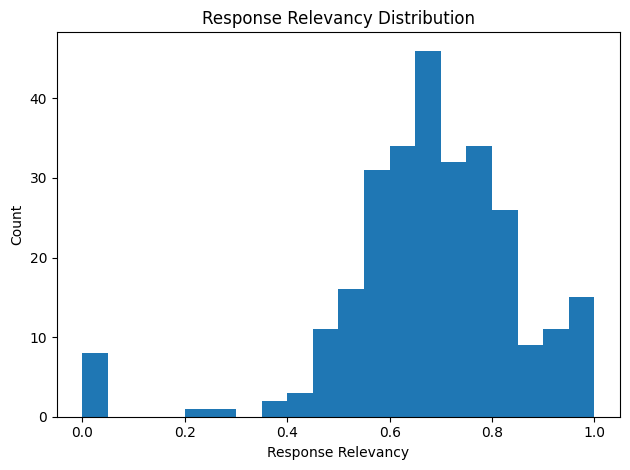

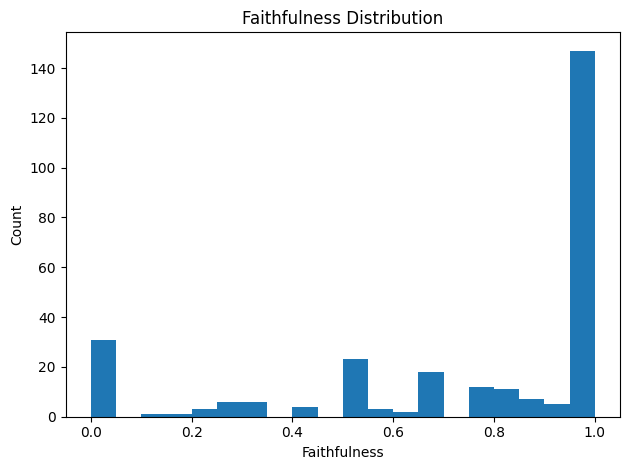

In [ ]:
def plot_histogram(values, title, xlabel):
    plt.figure()
    plt.hist(values, bins=20)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_histogram(cp_vals, "Context Precision Distribution", "Context Precision")
plot_histogram(rr_vals, "Response Relevancy Distribution", "Response Relevancy")
plot_histogram(f_vals, "Faithfulness Distribution", "Faithfulness")